<a href="https://colab.research.google.com/drive/1FeU5dUwyPAto4Sc9jBli5Pu1duIQX7hp">Abre este Jupyter en Google Colab</a>

# Visualización del conjunto de datos

En este notebook se muestran algunos de los mecanismos más utilizados para la visualización del conjunto de datos.

## Conjunto de datos

### Descripción
NSL-KDD is a data set suggested to solve some of the inherent problems of the KDD'99 data set which are mentioned in. Although, this new version of the KDD data set still suffers from some of the problems discussed by McHugh and may not be a perfect representative of existing real networks, because of the lack of public data sets for network-based IDSs, we believe it still can be applied as an effective benchmark data set to help researchers compare different intrusion detection methods. Furthermore, the number of records in the NSL-KDD train and test sets are reasonable. This advantage makes it affordable to run the experiments on the complete set without the need to randomly select a small portion. Consequently, evaluation results of different research work will be consistent and comparable.

### Ficheros de datos
* <span style="color:green">**KDDTrain+.ARFF**: The full NSL-KDD train set with binary labels in ARFF format</span>
* <span style="color:green">**KDDTrain+.TXT**: The full NSL-KDD train set including attack-type labels and difficulty level in CSV format</span>
* KDDTrain+_20Percent.ARFF:	A 20% subset of the KDDTrain+.arff file
* KDDTrain+_20Percent.TXT:	A 20% subset of the KDDTrain+.txt file
* KDDTest+.ARFF:	The full NSL-KDD test set with binary labels in ARFF format
* KDDTest+.TXT:	The full NSL-KDD test set including attack-type labels and difficulty level in CSV format
* KDDTest-21.ARFF:	A subset of the KDDTest+.arff file which does not include records with difficulty level of 21 out of 21
* KDDTest-21.TXT:	A subset of the KDDTest+.txt file which does not include records with difficulty level of 21 out of 21

### Descarga de los ficheros de datos
https://iscxdownloads.cs.unb.ca/iscxdownloads/NSL-KDD/#NSL-KDD  Este enlace está obsoleto

### Referencias adicionales sobre el conjunto de datos
_M. Tavallaee, E. Bagheri, W. Lu, and A. Ghorbani, “A Detailed Analysis of the KDD CUP 99 Data Set,” Submitted to Second IEEE Symposium on Computational Intelligence for Security and Defense Applications (CISDA), 2009._
**Nota:** aunque el notebook original mencionaba archivos ARFF, en esta revisión se trabajará con los archivos `.txt` ya descargados en Google Drive.


## 1. Lectura del conjunto de datos

NOTA1: Descargué el archivo comprimido desde Kaggle:

[Dataset seguridad en redes](https://www.kaggle.com/datasets/hassan06/nslkdd)

Lo descargué y lo nominé como: "datasetKaggleNSLKDD.zip"

Lo descomprimí y seleccioné los archivos:

KDDTrain+.TXT: The full NSL-KDD train set including attack-type labels and difficulty level in CSV format

KDDTest+.TXT: The full NSL-KDD test set including attack-type labels and difficulty level in CSV format

Para trabajar con archivos CSV

NOTA2: Los archivos CSV no traen los nombres de las características (columns). Para ello, lo obtuve del paper mencionado al inicio de este notebook:

 "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "class", "difficulty"

    

NOTA3: En el encabezado de los archivos .ARFF se puede visualizar el nombre de cada uno de los atributos (inluyendo el class o label). Por lo tanto, desde aquí se obtuvieron la lista de nombres de los atributos para agregárselos a los archivos CSV que se generaron en este notebook.

    

NOTA4: Al comparar los archivos .TXT (estos no declaran los nombres de los atributos)  con los .ARFF se puede observar que en los archivos en .TXT, después del valor de la class para cada instancia o muestra, hay un valor entero que no corresponde a la lista de atributos, pero que al inicio del notebook, se dice que se llama "difficulty". Posteriormente, durante el proceso se elimina; no se hizo eliminó antes para evitar descompaginar la conversión de TXT a CSV

### Configuración para Google Colab y Google Drive
El notebook original leía archivos desde `datasets/NSL-KDD/`. En esta versión se adapta la carga para usar los archivos `KDDTrain+.txt` y `KDDTest+.txt` ubicados en `MyDrive/Datasets/NSL-KDD/`.

Además, se corrige la estructura de columnas para **NSL-KDD**, considerando:
- **41 atributos de entrada**
- **1 columna objetivo**: `class`
- **1 columna adicional**: `difficulty`

De esta forma, la lectura del archivo `.txt` queda alineada con la estructura real del dataset.


In [26]:
import os
import pandas as pd

# Detectar si estamos en Google Colab o en entorno local
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = "/content/drive/MyDrive/Datasets/NSL-KDD"
except ImportError:
    DATA_DIR = "."  # archivos en el mismo directorio que el notebook

TRAIN_PATH = os.path.join(DATA_DIR, "KDDTrain+.txt")
TEST_PATH = os.path.join(DATA_DIR, "KDDTest+.txt")

COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "class", "difficulty"
]

print("Ruta de entrenamiento:", TRAIN_PATH)
print("Ruta de prueba:", TEST_PATH)
print("¿Existe TRAIN_PATH?", os.path.exists(TRAIN_PATH))
print("¿Existe TEST_PATH?", os.path.exists(TEST_PATH))
print("Número de columnas esperadas:", len(COLUMN_NAMES))

Ruta de entrenamiento: .\KDDTrain+.txt
Ruta de prueba: .\KDDTest+.txt
¿Existe TRAIN_PATH? True
¿Existe TEST_PATH? True
Número de columnas esperadas: 43


Los nombres de columnas del dataset NSL-KDD provienen de:

👉 El dataset original KDD Cup 99 dataset

👉 Y del paper que yo mismo descargué:

📄 “A Detailed Analysis of the KDD CUP 99 Data Set” de Mahbod Tavallaee

El dataset NSL-KDD:

Es una versión mejorada del KDD Cup 99
Mantiene exactamente la misma estructura de atributos

👉 Eso significa que:

Los nombres de columnas NO vienen en el archivo

Pero están definidos formalmente en la documentación del dataset

📊 ¿Cuántas columnas hay?

41 features (atributos)

1 etiqueta (label)

1 columna opcional (difficulty level)

👉 Total:

42 o 43 columnas dependiendo del archivo

En este cuaderno son 43 columnas

In [2]:
def load_nsl_kdd_txt(data_path):
    """Carga un archivo .txt del dataset NSL-KDD y asigna nombres de columnas."""
    return pd.read_csv(data_path, header=None, names=COLUMN_NAMES)


In [3]:
# Lectura del conjunto de datos mediante funciones básicas de Python
with open(TRAIN_PATH, "r") as train_set:
    lineas = train_set.readlines()

print(f"Número de líneas leídas: {len(lineas)}")
lineas[:3]  # Mostramos las primeras 3 filas crudas


Número de líneas leídas: 125973


['0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.00,0.00,0.00,0.00,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20\n',
 '0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.00,0.00,0.00,0.00,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15\n',
 '0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.00,1.00,0.00,0.00,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19\n']

In [4]:
# Lectura del conjunto de datos utilizando la función definida
df = load_nsl_kdd_txt(TRAIN_PATH)
df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
df.shape

(125973, 43)

In [6]:
# Mostramos los ficheros en el directorio del conjunto de datos
os.listdir(DATA_DIR)


['6_Visualizacion_conjunto_datos_NSLSKDD.ipynb',
 'KDDTest+.txt',
 'KDDTrain+.txt']

En el notebook original se trabajaba con archivos ARFF.  
En esta adaptación **no es necesario instalar bibliotecas adicionales para ARFF**, porque leeremos directamente los archivos `.txt` del dataset NSL-KDD usando `pandas`.


In [7]:
# Verificación simple: en esta versión trabajaremos directamente con archivos .txt
print("Se omite la instalación de liac-arff: trabajaremos con archivos .txt")


Se omite la instalación de liac-arff: trabajaremos con archivos .txt


In [8]:
# Primeras filas del conjunto de datos
df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [9]:
# Tipos de datos detectados por Pandas
df.dtypes


duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [10]:
# La función ya fue definida anteriormente y se reutiliza cuando sea necesario.
df_train = load_nsl_kdd_txt(TRAIN_PATH)
df_test = load_nsl_kdd_txt(TEST_PATH)

print("Forma del training set:", df_train.shape)
print("Forma del test set:", df_test.shape)


Forma del training set: (125973, 43)
Forma del test set: (22544, 43)


## 2. Funciones básicas de visualización de los datos

* El proceso de visualización siempre debe realizarse sobre el trainning set y apartando el test set. Esto evita que nuestro cerebro genere intuiciones del test set que podemos incorporar en nuestro modelo
* Una buena práctica es crear una copia del trainning set y jugar con ella. De esta manera, si realizamos transformaciones que dañan el tranning set, el original no se ve afectado

In [11]:
# Para el resto del notebook trabajaremos con una copia del training set
df = df_train.copy()
df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [12]:
# Mostrar en pantalla un número determinado de filas
df.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [13]:
# Mostrar información básica sobre el conjunto de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [14]:
# Mostrar información estadística sobre el conjunto de datos
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


📊 Significado de los valores

🔹 1. count

👉 Cantidad de datos no nulos

Indica cuántos valores existen en esa columna
Sirve para detectar datos faltantes

📌 Ejemplo:

Si tienes 1000 filas pero count = 950
👉 hay 50 valores faltantes

🔹 2. 25% (Primer cuartil, Q1)

👉 Valor por debajo del cual está el 25% de los datos

Divide el 25% inferior del dataset

Indica valores “bajos”

📌 Interpretación:

“El 25% de los datos es menor o igual a este valor”

🔹 3. 50% (Mediana, Q2)

👉 Valor central del conjunto de datos

Es el punto donde:

50% de los datos están abajo

50% están arriba

📌 Muy importante:

Es más robusto que el promedio (mean) frente a outliers

🔹 4. 75% (Tercer cuartil, Q3)

👉 Valor por debajo del cual está el 75% de los datos

Marca el límite superior “normal” de los datos

📌 Interpretación:

“El 75% de los datos es menor o igual a este valor”

🧠 Visualización mental (muy útil para clase)

Imagina los datos ordenados:

|----25%----|----50%----|----75%----|

mín ------- Q1------ mediana -------Q3 --------máx


🎯 ¿Para qué sirve esto?

🔹 Detectar dispersión

Si Q1 y Q3 están muy separados => datos dispersos

🔹 Detectar outliers

Valores muy fuera de Q1–Q3

👉 Regla típica:

IQR = Q3 - Q1

In [15]:
# Mostrar los valores únicos que tiene un atributo determinado
df["protocol_type"].value_counts()

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

In [16]:
# Mostrar la distribución de la clase objetivo
df["class"].value_counts()


class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

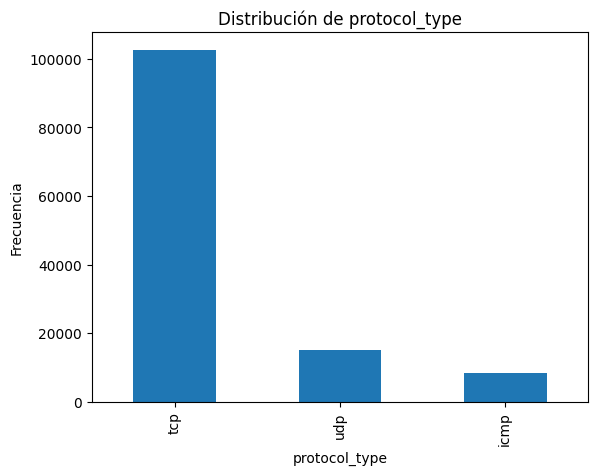

In [17]:
# Representación gráfica de una característica categórica
%matplotlib inline
import matplotlib.pyplot as plt

df["protocol_type"].value_counts().plot(kind="bar")
plt.title("Distribución de protocol_type")
plt.xlabel("protocol_type")
plt.ylabel("Frecuencia")
plt.show()


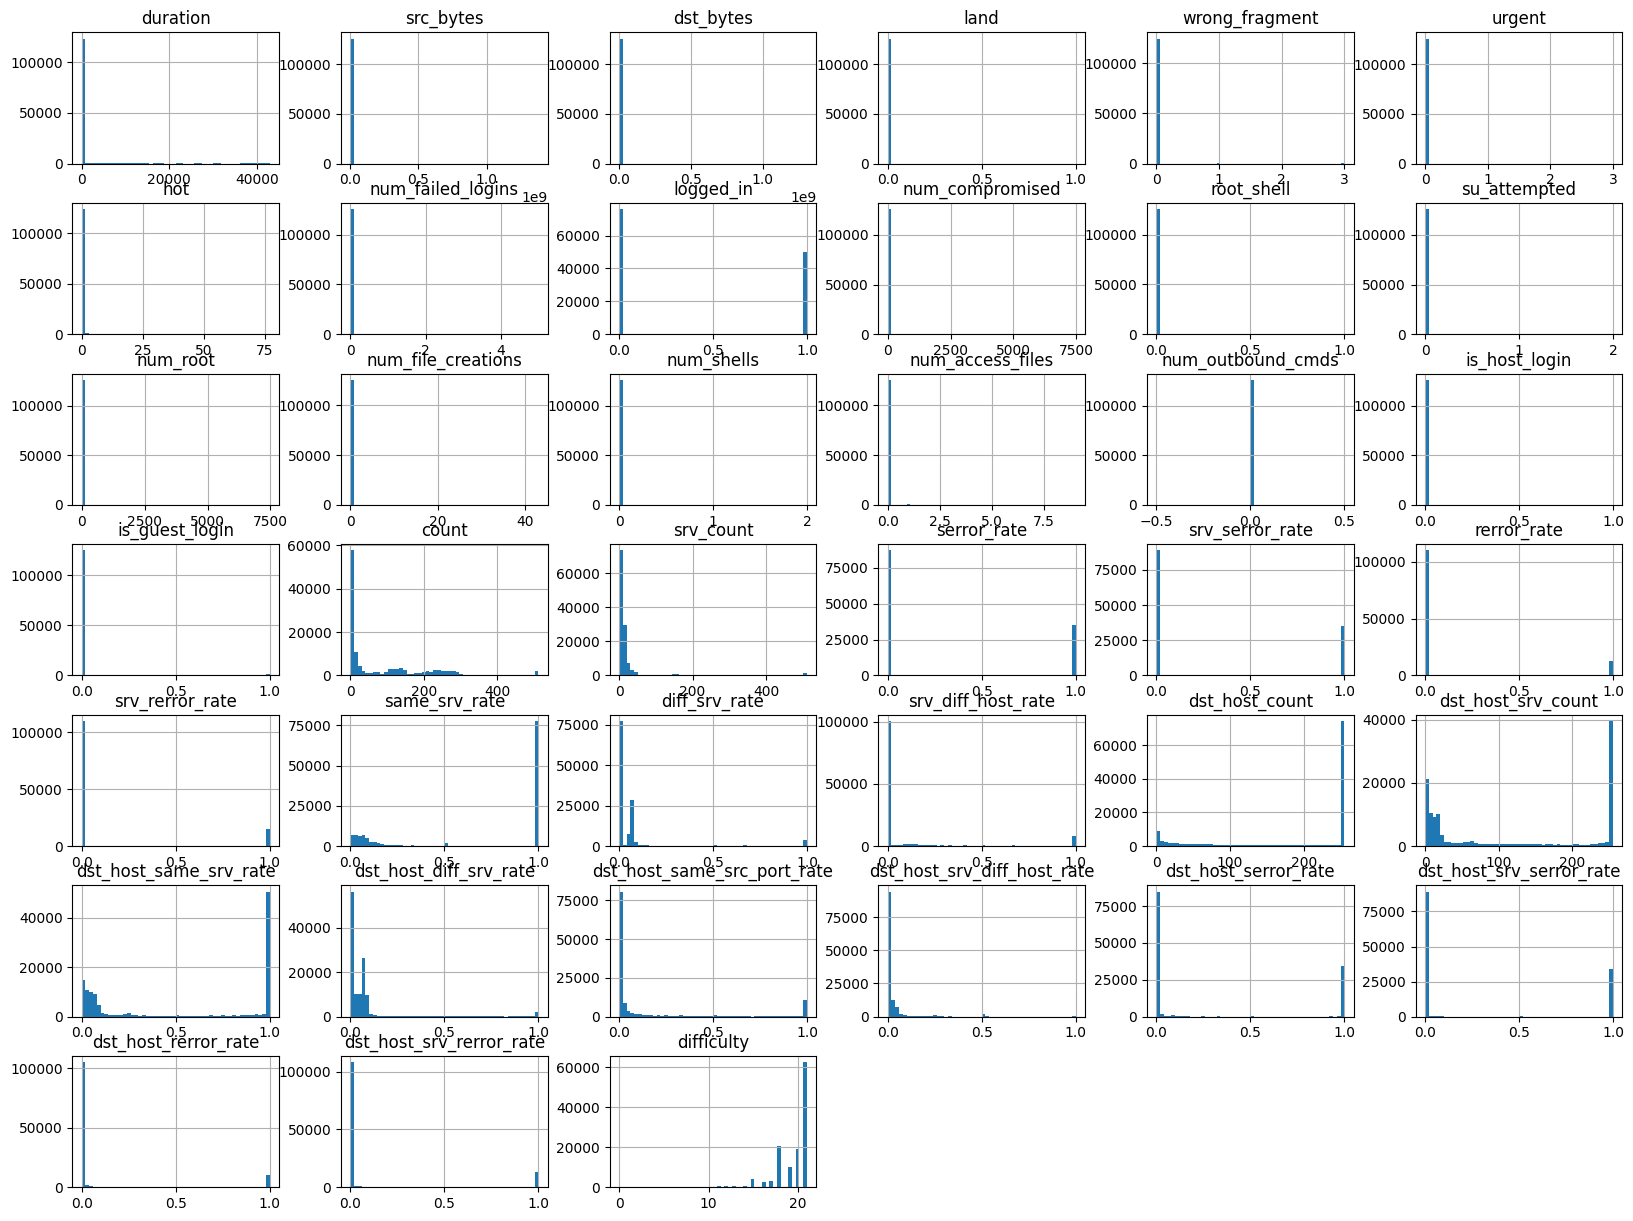

In [18]:
# Representar gráficamente la distribución de los atributos
df.hist(bins=50, figsize=(20,15))
plt.show()

## 3. Funciones avanzadas de visualización de los datos

### Buscando correlaciones

* Se puede calcular el coeficiente de correlación estándar para ver la correlación entre cada par de atributos.
* El coeficiente de correlación solo mide **correlaciones lineales**.
* Para calcular correlaciones, primero hay que convertir a valores numéricos la variable objetivo `class` y los atributos categóricos.


In [19]:
# El atributo class de nuestro conjunto de datos tiene valores categoricos
df["class"]

0          normal
1          normal
2         neptune
3          normal
4          normal
           ...   
125968    neptune
125969     normal
125970     normal
125971    neptune
125972     normal
Name: class, Length: 125973, dtype: str

In [20]:
from sklearn.preprocessing import LabelEncoder

# Transformamos los valores del atributo class de categoricos a numéricos
labelencoder = LabelEncoder()
df["class"] = labelencoder.fit_transform(df["class"])

# Transformamos los valores de los atributos categóricos a numéricos
df["protocol_type"] = labelencoder.fit_transform(df["protocol_type"])
df["service"] = labelencoder.fit_transform(df["service"])
df["flag"] = labelencoder.fit_transform(df["flag"])

df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,11,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,11,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,9,19
3,0,1,24,9,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,11,21
4,0,1,24,9,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,9,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,11,21
125970,0,1,54,9,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,11,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,9,20


In [21]:
# Mostrar la correlación entre los atributos del conjunto de datos
corr_matrix = df.corr(numeric_only=True)
corr_matrix["class"].sort_values(ascending=False)

class                          1.000000
srv_count                      0.310819
wrong_fragment                 0.304125
dst_host_diff_srv_rate         0.295042
same_srv_rate                  0.258357
diff_srv_rate                  0.228557
dst_host_same_src_port_rate    0.202229
flag                           0.170749
dst_host_srv_count             0.138848
protocol_type                  0.135203
duration                       0.134590
is_guest_login                 0.109112
dst_host_rerror_rate           0.108057
dst_host_srv_rerror_rate       0.106217
logged_in                      0.104056
rerror_rate                    0.099397
hot                            0.098611
srv_rerror_rate                0.098105
dst_host_same_srv_rate         0.073548
count                          0.060380
dst_host_count                 0.053869
src_bytes                      0.011617
dst_bytes                      0.007600
num_access_files               0.005220
su_attempted                   0.004005


In [22]:
# Mostrar correlación lineal entre todos los atributos del conjunto de datos
df.corr(numeric_only=True)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
duration,1.000000,0.038241,0.092858,-0.063390,0.070737,0.034878,-0.001553,-0.009866,0.003830,0.000705,...,-0.116005,0.254195,0.228737,-0.026669,-0.064948,-0.064361,0.173815,0.199024,0.134590,-0.156311
protocol_type,0.038241,1.000000,0.029994,0.093668,-0.000974,-0.000608,-0.001757,0.169535,-0.000965,-0.011857,...,0.001702,0.131380,-0.209105,-0.356183,-0.079398,-0.077925,-0.015434,-0.046938,0.135203,0.082775
service,0.092858,0.029994,1.000000,-0.304014,-0.001631,0.003596,-0.009952,0.084404,0.010980,-0.064066,...,-0.452696,0.284072,-0.111163,-0.156211,0.281635,0.277594,0.150666,0.148405,-0.001798,0.033724
flag,-0.063390,0.093668,-0.304014,1.000000,-0.008114,-0.004096,-0.010373,0.067214,0.005811,0.068437,...,0.630118,-0.283607,0.195689,0.073773,-0.443441,-0.443225,-0.683310,-0.718778,0.170749,0.054179
src_bytes,0.070737,-0.000974,-0.001631,-0.008114,1.000000,0.000204,-0.000109,-0.000693,-0.000059,0.000295,...,-0.006572,0.000900,0.000431,-0.001655,-0.004503,-0.003397,-0.001468,0.012449,0.011617,-0.022592
dst_bytes,0.034878,-0.000608,0.003596,-0.004096,0.000204,1.000000,-0.000069,-0.000440,0.000248,-0.000344,...,-0.004424,0.011031,0.011747,-0.001281,-0.003024,-0.002944,0.011729,0.011223,0.007600,-0.018076
land,-0.001553,-0.001757,-0.009952,-0.010373,-0.000109,-0.000069,1.000000,-0.001261,-0.000109,-0.001340,...,0.011597,-0.004516,0.033851,0.070474,0.019840,0.012276,-0.005222,-0.005303,-0.017239,-0.037038
wrong_fragment,-0.009866,0.169535,0.084404,0.067214,-0.000693,-0.000440,-0.001261,1.000000,-0.000692,-0.008508,...,-0.048733,0.059797,0.037177,-0.016252,-0.051917,-0.055917,0.028890,-0.033682,0.304125,-0.157130
urgent,0.003830,-0.000965,0.010980,0.005811,-0.000059,0.000248,-0.000109,-0.000692,1.000000,0.000293,...,-0.004489,0.006840,0.002741,0.005176,-0.004749,-0.004834,-0.002999,-0.002912,-0.003513,-0.016411
hot,0.000705,-0.011857,-0.064066,0.068437,0.000295,-0.000344,-0.001340,-0.008508,0.000293,1.000000,...,-0.036293,-0.012293,-0.034536,-0.024715,-0.058222,-0.058214,-0.030555,-0.031670,0.098611,-0.160013


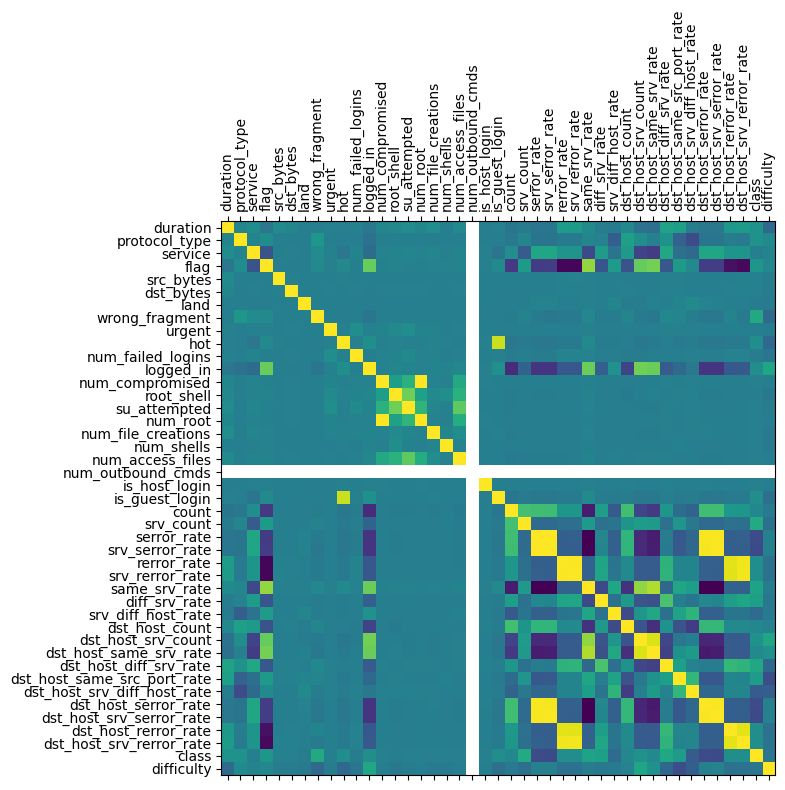

In [23]:
# Representar gráficamente la matriz de correlación
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
ax.matshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

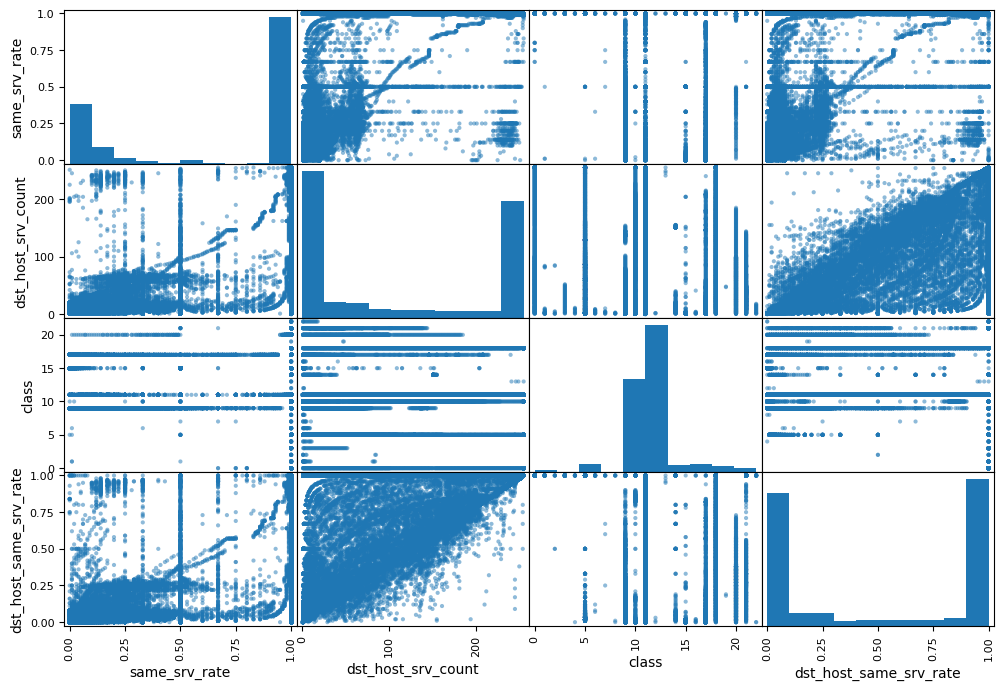

In [24]:
# Representar gráficamente las correlaciones
from pandas.plotting import scatter_matrix

attributes = ["same_srv_rate", "dst_host_srv_count", "class", "dst_host_same_srv_rate"]

scatter_matrix(df[attributes], figsize=(12,8))
plt.show()

In [25]:
# Mostrar la correlación entre los atributos del conjunto de datos
corr_matrix = df.corr(numeric_only=True)
corr_matrix["class"].sort_values(ascending=False)

class                          1.000000
srv_count                      0.310819
wrong_fragment                 0.304125
dst_host_diff_srv_rate         0.295042
same_srv_rate                  0.258357
diff_srv_rate                  0.228557
dst_host_same_src_port_rate    0.202229
flag                           0.170749
dst_host_srv_count             0.138848
protocol_type                  0.135203
duration                       0.134590
is_guest_login                 0.109112
dst_host_rerror_rate           0.108057
dst_host_srv_rerror_rate       0.106217
logged_in                      0.104056
rerror_rate                    0.099397
hot                            0.098611
srv_rerror_rate                0.098105
dst_host_same_srv_rate         0.073548
count                          0.060380
dst_host_count                 0.053869
src_bytes                      0.011617
dst_bytes                      0.007600
num_access_files               0.005220
su_attempted                   0.004005
